# 1 三角函数、极坐标、复数与欧拉公式：角度、幅度、相位与频率

本文整理「角度—幅度—相位—频率」在振动与信号语境下的含义，并说明正弦类函数、极坐标、复数与欧拉公式如何统一在同一套语言里。便于阅读 RoPE、傅里叶与旋转相关的实现。

**配套可视化**：下面代码单元格给出简谐振动、极坐标与复平面的示意图（运行后即可查看）。

---

## 1. 一元简谐振动：幅度、相位、角频率、频率

考虑随时间 $t$ 变化的标量信号，最简形式为：

$$
x(t) = A\cos(\omega t + \varphi).
$$

- **幅度（振幅）$A$**：振荡离开平衡位置的最大尺度，$A \ge 0$。决定「波有多高」，不改变振荡快慢。
- **初相 $\varphi$**：$t=0$ 时刻振荡处在周期中的位置；单位与 $\omega t$ 相同，一般为**弧度**。整体加 $\varphi$ 等价于把时间轴平移：同一频率下只改变「起点在周期里的哪一点」。
- **角频率 $\omega$**：相位随时间变化的快慢，$\dfrac{d}{dt}(\omega t + \varphi) = \omega$（弧度/秒）。**一个完整周期**对应相位增加 $2\pi$，故周期 $T = 2\pi/\omega$。
- **频率 $f$**：单位时间内完成的周期数（Hz，即「次/秒」）。与角频率的关系为：

$$
\omega = 2\pi f,\qquad f = \frac{1}{T}.
$$

**小结**：**幅度**管大小；**频率/角频率**管振荡快慢（相位对时间的导数）；**相位**管同一频率下波在时间轴上的平移（初相）或不同通道间的相对延迟。

---

## 2. 角度与相位：何时都叫「角」

- **几何角**：平面上的方向，常用弧度度量。
- **相位**：在周期现象里，把「完成了周期的几分之几」映射到 $[0, 2\pi)$ 或整条实轴上；对 $\cos(\cdot)$、$\sin(\cdot)$ 而言，括号里的量就是**以弧度计的角度**，也是**相位**。

因此：**相位本质上是参与周期函数自变量的那个角**；说「旋转 $\theta$」与说「相位增加 $\theta$」在匀速圆运动/复平面上常指同一件事。

---

**可视化（简谐振动）**：下一单元格绘制 $x(t)=A\cos(\omega t+\varphi)$。左：同一 $A,\omega$，不同初相 $\varphi$（波形左右平移）；中：同一 $A,\varphi$，不同 $\omega$（振荡快慢）；右：同一 $\omega,\varphi$，不同 $A$（纵向缩放）。竖虚线标出一个周期 $T=2\pi/\omega$（取中间子图的参数）。


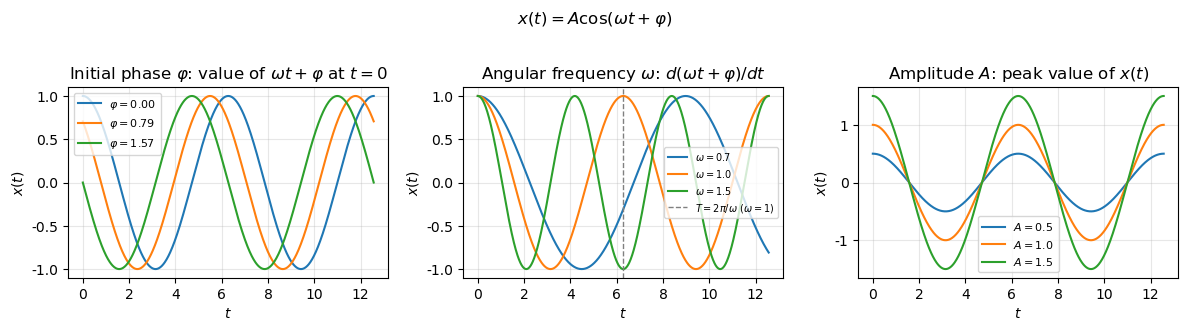

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

t = np.linspace(0, 4 * np.pi, 800)
A0, w0 = 1.0, 1.0

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

# Initial phase: shift along the time axis
phis = [0, np.pi / 4, np.pi / 2]
for phi in phis:
    axes[0].plot(t, A0 * np.cos(w0 * t + phi), label=rf"$\varphi={phi:.2f}$")
axes[0].set_title(r"Initial phase $\varphi$: value of $\omega t+\varphi$ at $t=0$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$x(t)$")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Angular frequency: how fast the wave oscillates
ws = [0.7, 1.0, 1.5]
for w in ws:
    axes[1].plot(t, A0 * np.cos(w * t), label=rf"$\omega={w}$")
T_mark = 2 * np.pi / 1.0
axes[1].axvline(T_mark, color="gray", ls="--", lw=1, label=rf"$T=2\pi/\omega$ ($\omega=1$)")
axes[1].set_title(r"Angular frequency $\omega$: $d(\omega t+\varphi)/dt$")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$x(t)$")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Amplitude
amps = [0.5, 1.0, 1.5]
for A in amps:
    axes[2].plot(t, A * np.cos(w0 * t), label=rf"$A={A}$")
axes[2].set_title(r"Amplitude $A$: peak value of $x(t)$")
axes[2].set_xlabel("$t$")
axes[2].set_ylabel("$x(t)$")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(r"$x(t)=A\cos(\omega t+\varphi)$", y=1.02)
plt.tight_layout()
plt.show()

## 3. 三角函数与极坐标

平面直角坐标 $(x, y)$ 与极坐标 $(r, \theta)$ 的关系为：

$$
x = r\cos\theta,\qquad y = r\sin\theta,
$$

其中 $r \ge 0$ 为到原点的距离（模长），$\theta$ 为从正 $x$ 轴逆时针转过的角（辐角）。

- **$r$**：与简谐振动里的**幅度**角色类似（这里是二维矢量的长度）。
- **$\theta$**：方向角，与**相位**使用同一套弧度语言。

同一点既可写 $(x,y)$，也可写 $(r,\theta)$；三角函数是两种坐标之间的桥梁。

---

## 4. 复数：直角形式、极形式与欧拉公式

复数 $z$ 可写：

- **代数（直角）形式**：$z = a + bi$，其中 $a=\operatorname{Re}(z)$，$b=\operatorname{Im}(z)$。
- **极形式**：$z = r(\cos\theta + i\sin\theta)$，其中 $r = |z| = \sqrt{a^2+b^2}$，$\theta = \arg(z)$（辐角，与极坐标中的 $\theta$ 一致，差 $2\pi$ 的整数倍）。

**欧拉公式**：

$$
e^{i\theta} = \cos\theta + i\sin\theta.
$$

因此极形式可紧凑地写成：

$$
z = r e^{i\theta}.
$$

- **$r$**：复数的**模（幅度）**。
- **$\theta$**：**辐角（相位）**。
- 乘以 $e^{i\theta}$：**保持模不变，整体逆时针旋转 $\theta$**。这在 RoPE 等「位置相关的旋转」里是直接对应的图像。

由欧拉公式可得：

$$
\cos\theta = \frac{e^{i\theta} + e^{-i\theta}}{2},\qquad
\sin\theta = \frac{e^{i\theta} - e^{-i\theta}}{2i}.
$$

即：**三角函数是复指数的对称组合**；匀速圆周运动 $e^{i(\omega t + \varphi)}$ 的实部、虚部分别是余弦、正弦形式的简谐振动。

---

## 5. 一张关系图（概念上）

```text
简谐振动 x(t)=A cos(ωt+φ)
        ↔  相位 (ωt+φ) 进入 cos/sin
        ↔  复平面上的旋转 A·e^{i(ωt+φ)} 的实部（或虚部）
        ↔  极坐标 (r,θ) 中 r=A, θ=ωt+φ 在实轴上的投影

频率 f、角频率 ω：决定 θ 随 t 增长的快慢（dθ/dt = ω = 2πf）
幅度 A / 模 r：决定长度
相位 φ 或 θ：决定在周期（或圆）上的位置
```

**可视化（极坐标与复平面）**：下一单元格左图：极坐标 $(r,\theta)$ 与直角坐标 $(x,y)$；右图：单位圆上的 $e^{i\theta}$，实部/虚部即 $\cos\theta,\sin\theta$（旋转与 RoPE 的直觉一致）。

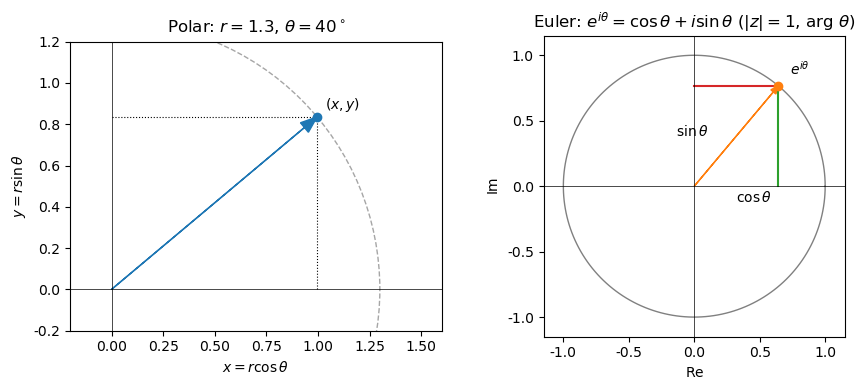

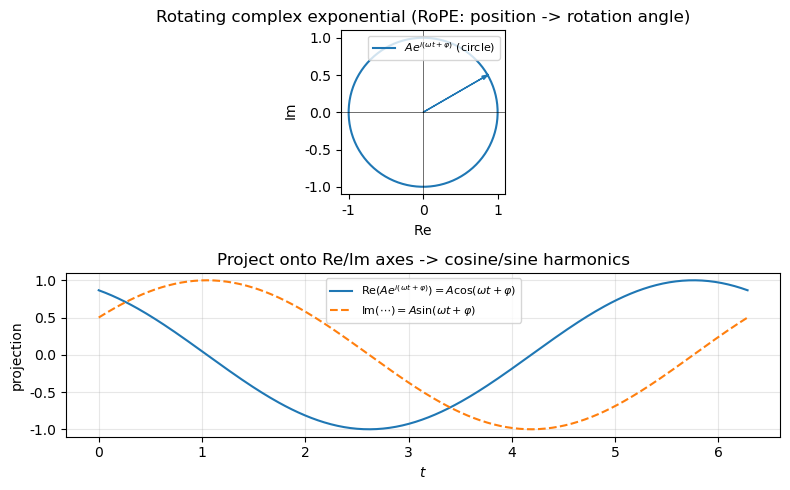

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# --- Polar vs. Cartesian ---
ax = axes[0]
r, theta = 1.3, np.deg2rad(40)
x, y = r * np.cos(theta), r * np.sin(theta)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
circle = plt.Circle((0, 0), r, fill=False, ls="--", color="gray", alpha=0.7)
ax.add_patch(circle)
ax.arrow(0, 0, x, y, head_width=0.06, head_length=0.08, fc="C0", ec="C0", length_includes_head=True)
ax.plot([x, x], [0, y], "k:", lw=0.8)
ax.plot([0, x], [y, y], "k:", lw=0.8)
ax.scatter([x], [y], c="C0", zorder=5)
ax.annotate(r"$(x,y)$", (x, y), xytext=(6, 6), textcoords="offset points")
ax.set_aspect("equal")
ax.set_xlim(-0.2, 1.6)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("$x=r\\cos\\theta$")
ax.set_ylabel("$y=r\\sin\\theta$")
ax.set_title(rf"Polar: $r={r}$, $\theta={np.rad2deg(theta):.0f}^\circ$")

# --- Euler on the unit circle ---
ax2 = axes[1]
th = np.linspace(0, 2 * np.pi, 200)
ax2.plot(np.cos(th), np.sin(th), color="gray", lw=1)
theta0 = np.deg2rad(50)
c, s = np.cos(theta0), np.sin(theta0)
ax2.arrow(0, 0, c, s, head_width=0.05, head_length=0.06, fc="C1", ec="C1", length_includes_head=True)
ax2.plot([c, c], [0, s], "C2", lw=1.5)
ax2.plot([0, c], [s, s], "C3", lw=1.5)
ax2.scatter([c], [s], c="C1", zorder=5)
ax2.annotate(r"$e^{i\theta}$", (c, s), xytext=(8, 8), textcoords="offset points")
ax2.annotate(r"$\cos\theta$", (c / 2, -0.12))
ax2.annotate(r"$\sin\theta$", (-0.14, s / 2))
ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(0, color="k", lw=0.5)
ax2.set_aspect("equal")
ax2.set_xlim(-1.15, 1.15)
ax2.set_ylim(-1.15, 1.15)
ax2.set_xlabel(r"$\mathrm{Re}$")
ax2.set_ylabel(r"$\mathrm{Im}$")
ax2.set_title(r"Euler: $e^{i\theta}=\cos\theta+i\sin\theta$ ($|z|=1$, arg $\theta$)")

plt.tight_layout()
plt.show()

# Phasor: x(t)=Re(A e^{i(ωt+φ)}); uniform rotation in the complex plane
omega, phi, A = 1.0, np.pi / 6, 1.0
t2 = np.linspace(0, 2 * np.pi / omega, 300)
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(8, 5), gridspec_kw={"height_ratios": [1, 1]})
z_traj = A * np.exp(1j * (omega * t2 + phi))
ax3.plot(np.real(z_traj), np.imag(z_traj), label=r"$A e^{i(\omega t+\varphi)}$ (circle)")
ax3.arrow(0, 0, np.real(z_traj[0]), np.imag(z_traj[0]), head_width=0.05, fc="C0", ec="C0", length_includes_head=True)
ax3.set_aspect("equal")
ax3.axhline(0, color="k", lw=0.4)
ax3.axvline(0, color="k", lw=0.4)
ax3.set_xlabel(r"$\mathrm{Re}$")
ax3.set_ylabel(r"$\mathrm{Im}$")
ax3.legend(loc="upper right", fontsize=8)
ax3.set_title("Rotating complex exponential (RoPE: position -> rotation angle)")

ax4.plot(t2, np.real(z_traj), label=r"$\mathrm{Re}(A e^{i(\omega t+\varphi)})=A\cos(\omega t+\varphi)$")
ax4.plot(t2, np.imag(z_traj), "--", label=r"$\mathrm{Im}(\cdots)=A\sin(\omega t+\varphi)$")
ax4.set_xlabel("$t$")
ax4.set_ylabel("projection")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_title("Project onto Re/Im axes -> cosine/sine harmonics")

plt.tight_layout()
plt.show()

## 6. 与实现的一点联系（如 PyTorch）

- `torch.polar(abs, angle)`：由模长与辐角构造复数，对应 $r e^{i\theta}$。
- `torch.angle(z)`、`torch.abs(z)`：从复数取出相位与幅度，与上文记号一致。

理解「相位 = 旋转角」「$e^{i\theta}$ = 旋转因子」后，RoPE 里对特征按位置乘旋转矩阵或等价复数旋转，与上面的**复平面旋转**、**投影得到 cos/sin** 是同一脉络。

---

## 7. 参考式子速查

| 概念 | 记号 | 与相邻概念的关系 |
|------|------|------------------|
| 角频率与频率 | $\omega,\, f$ | $\omega = 2\pi f$ |
| 周期 | $T$ | $T = 1/f = 2\pi/\omega$ |
| 简谐振动 | $A\cos(\omega t+\varphi)$ | 幅度 $A$，初相 $\varphi$ |
| 极坐标 | $(r,\theta)$ | $x=r\cos\theta,\; y=r\sin\theta$ |
| 欧拉公式 | $e^{i\theta}$ | $\cos\theta + i\sin\theta$ |
| 复数极形式 | $z$ | $z = r e^{i\theta}$ |

## 极坐标《-》复数坐标

复数坐标c = a + bi ，a=mod_len*cos(deg)=1.0*cos(45.0), b=mod_len*sin(deg)=1.0*sin(45.0)
c: (0.7071067690849304+0.7071067690849304j)


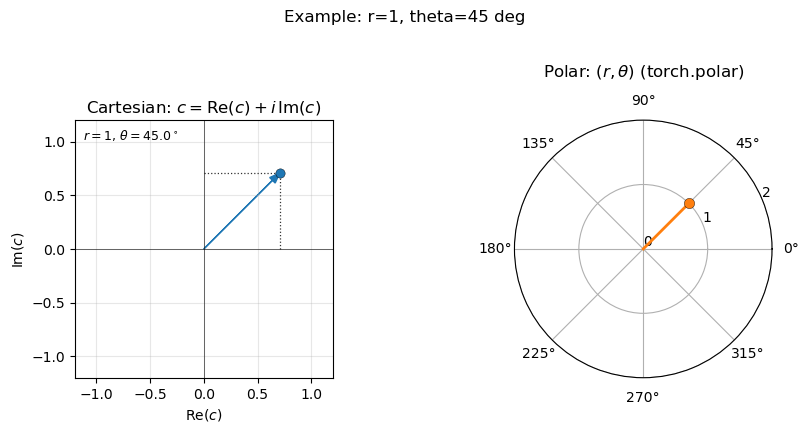

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def plot_complex_cartesian_polar(
    re,
    im,
    figsize=(9.5, 4.2),
    polar_title=r"Polar: $(r,\theta)$",
    suptitle=None,
):
    """Draw Cartesian (Re/Im) and polar (r, theta) views for one complex number."""
    re, im = float(re), float(im)
    mod_len = float(np.hypot(re, im))
    if mod_len < 1e-12:
        raise ValueError("modulus is zero; nothing to plot")
    theta_rad = float(np.arctan2(im, re))
    deg = float(np.rad2deg(theta_rad))

    fig = plt.figure(figsize=figsize)
    if suptitle:
        fig.suptitle(suptitle, y=1.02)

    lim = max(mod_len * 1.2, 0.6)
    hw = min(0.15, 0.06 * lim)
    hl = min(0.2, 0.08 * lim)

    ax0 = fig.add_subplot(1, 2, 1)
    ax0.axhline(0, color="k", lw=0.4)
    ax0.axvline(0, color="k", lw=0.4)
    ax0.arrow(0, 0, re, im, head_width=hw, head_length=hl, fc="C0", ec="C0", length_includes_head=True)
    ax0.scatter([re], [im], c="C0", s=45, zorder=5, edgecolors="k", linewidths=0.3)
    ax0.plot([re, re], [0, im], "k:", lw=0.9, alpha=0.8)
    ax0.plot([0, re], [im, im], "k:", lw=0.9, alpha=0.8)
    ax0.set_aspect("equal")
    ax0.set_xlim(-lim, lim)
    ax0.set_ylim(-lim, lim)
    ax0.set_xlabel(r"$\mathrm{Re}(c)$")
    ax0.set_ylabel(r"$\mathrm{Im}(c)$")
    ax0.set_title(r"Cartesian: $c=\mathrm{Re}(c)+i\,\mathrm{Im}(c)$")
    ax0.grid(True, alpha=0.3)
    ax0.text(
        0.03,
        0.97,
        rf"$r={mod_len:.4g}$, $\theta={deg:.1f}^\circ$",
        transform=ax0.transAxes,
        va="top",
        fontsize=9,
    )

    axp = fig.add_subplot(1, 2, 2, projection="polar")
    axp.plot([0, theta_rad], [0, mod_len], color="C1", lw=2)
    axp.scatter([theta_rad], [mod_len], color="C1", s=55, zorder=5, edgecolors="k", linewidths=0.3)
    r_max = mod_len * 1.12
    axp.set_rlim(0, r_max)
    axp.set_rticks(np.arange(0, int(np.ceil(r_max)) + 1))
    axp.set_title(polar_title, pad=12)

    plt.tight_layout()
    plt.show()


# Demo: built from polar form (torch.polar)
mod_len = 1.0  # 模长为1
deg = 45.0  # 角度为45度
c = torch.polar(
    torch.tensor(mod_len, dtype=torch.float32),
    torch.deg2rad(torch.tensor(deg, dtype=torch.float32)),
)
print(f"复数坐标c = a + bi ，a=mod_len*cos(deg)={mod_len}*cos({deg}), b=mod_len*sin(deg)={mod_len}*sin({deg})")
print(f"c: {c}")
z = c.detach().cpu().numpy().squeeze()
re, im = float(np.real(z)), float(np.imag(z))
plot_complex_cartesian_polar(
    re,
    im,
    polar_title=r"Polar: $(r,\theta)$ (torch.polar)",
    suptitle="Example: r=1, theta=45 deg",
)

c_cartesian: (2+3j)
re: 2.0, im: 3.0, angle: 0.982793723247329, mod_len: 3.605551275463989
c_polar: (2+3j)


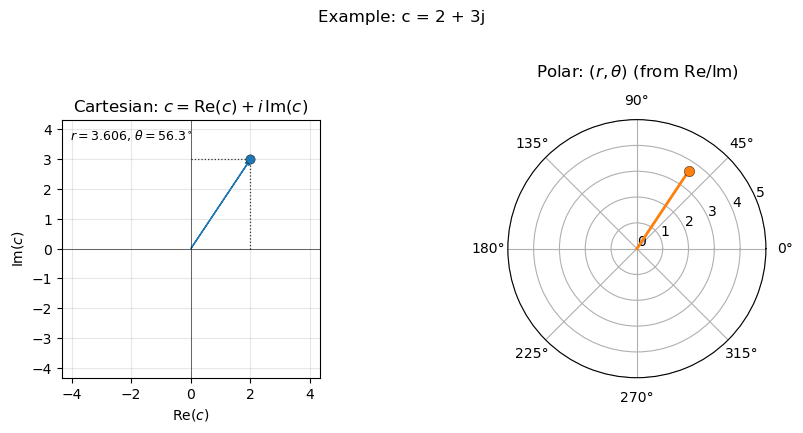

In [33]:
# Cartesian form -> same visualization (run cell above for plot_complex_cartesian_polar)
import math
import numpy as np
import torch


def complex_scalar_to_polar(z):
    """Re, Im, angle=atan2(Im,Re), modulus from a scalar complex (numpy or Python). No np.real/angle/abs."""
    re = float(z.real)
    im = float(z.imag)
    mod_len = (re * re + im * im) ** 0.5
    angle = math.atan2(im, re)
    return re, im, angle, mod_len


c = torch.complex(torch.tensor(2.0), torch.tensor(3.0))
print(f"c_cartesian: {c}")

z = c.detach().cpu().numpy().squeeze()
re, im, angle, mod_len = complex_scalar_to_polar(z)
print(f"re: {re}, im: {im}, angle: {angle}, mod_len: {mod_len}")

c_polar = torch.polar(torch.tensor(mod_len), torch.tensor(angle))
print(f"c_polar: {c_polar}")

plot_complex_cartesian_polar(
    re,
    im,
    polar_title=r"Polar: $(r,\theta)$ (from Re/Im)",
    suptitle="Example: c = 2 + 3j",
)

# RoPE 二维旋转位置编码：为什么是「两个复数相乘」

（对应论文 **§3.2.1 二维情形**：复数形式式 (12) 与矩阵形式式 (13)。）

## 1. 二维特征看成复数

把 head 里相邻两维 $(x^{(1)}, x^{(2)})$ 拼成一个复数

$$
z = x^{(1)} + i\,x^{(2)}.
$$

在复平面上，$z$ 就是向量 $(x^{(1)}, x^{(2)})$。**乘以单位模复数** $e^{i\phi}=\cos\phi + i\sin\phi$ 时，由定义恒有

$$
\cos^2\phi + \sin^2\phi = 1,
$$

故 $|e^{i\phi}|^2 = (\cos\phi)^2 + (\sin\phi)^2 = 1$，即 $|e^{i\phi}|=1$：该因子落在**单位圆**上，与任意 $z$ 相乘时**保持模长** $|e^{i\phi} z| = |e^{i\phi}|\,|z| = |z|$，只把辐角平移 $\phi$。

先把 $e^{i\phi} z = (\cos\phi + i\sin\phi)(x^{(1)} + i x^{(2)})$ **逐项相乘**（注意 $i^2=-1$）：

$$
\begin{aligned}
(\cos\phi + i\sin\phi)(x^{(1)} + i x^{(2)})
&= \cos\phi\,x^{(1)} + i\cos\phi\,x^{(2)} + i\sin\phi\,x^{(1)} + i^2\sin\phi\,x^{(2)} \\
&= \big(x^{(1)}\cos\phi - x^{(2)}\sin\phi\big) + i\big(x^{(1)}\sin\phi + x^{(2)}\cos\phi\big).
\end{aligned}
$$

因此

$$
\operatorname{Re}(e^{i\phi} z) = x^{(1)}\cos\phi - x^{(2)}\sin\phi,\qquad
\operatorname{Im}(e^{i\phi} z) = x^{(1)}\sin\phi + x^{(2)}\cos\phi,
$$

即 $\begin{pmatrix}\cos\phi & -\sin\phi\\ \sin\phi & \cos\phi\end{pmatrix}\begin{pmatrix}x^{(1)}\\ x^{(2)}\end{pmatrix}$。

把实部、虚部写成上式，正好等价于用 $2\times 2$ **旋转矩阵**作用在列向量 $\begin{pmatrix}x^{(1)}\\ x^{(2)}\end{pmatrix}$ 上（即式 (13) 里左边那个 $\begin{pmatrix}\cos m\theta & -\sin m\theta\\ \sin m\theta & \cos m\theta\end{pmatrix}$）。  
所以：**「旋转二维向量」=「乘一个模为 1 的复数」**。

## 2. 注意力内积、相对位置 $m-n$ 的关系

RoPE 希望 query/key 在进注意力时带上**位置**。因此可以将位置信息，编码到相位中，

两位置 $m,n$ 上各自乘了 $e^{im\theta}$、$e^{in\theta}$ 后，在合适的内积/实部定义下，相位里会出现

$$
e^{im\theta}\,\overline{e^{in\theta}} = e^{i(m-n)\theta},
$$

因此内积只依赖**相对位置** $m-n$，而不是各自绝对位置的简单相加。  
实现里用 `torch.polar` / 复数乘法批量做旋转，就是为这个代数结构服务。

**一句话**：二维 RoPE 本质是「特征二维块」在平面上的旋转；复数乘法 $z \cdot e^{i m\theta}$ 正是实现该旋转的最紧凑写法，与旋转矩阵完全等价。

# 计算每个位置的位置编码分量

In [ ]:
import torch

def precompute_freqs_cis(dim: int, max_seq_len: int = 4, theta: float = 10000.0):
    # 1 计算频率: 1/theta^(2i/dim): shape (dim // 2)
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)
                             [: (dim // 2)].float() / dim))
    # 2 计算相位(幅度角): 角频率 * 位置(t) : shape (max_seq_len, dim // 2)
    freqs = torch.outer(torch.arange(max_seq_len, device=freqs.device),
                        freqs).float()  # torch.outer 计算两个向量的外积
    # 3 使用极坐标转换为复数向量存储: 模长为1，相位为幅度角，即将vector的每个分量映射到复平面上，长度都为1，但是具备不同的角度
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)
    return freqs_cis


## 可视化分量

In [10]:
dim = 8  # head_dim
max_seq_len = 4
theta = 1000.0
freqs_cis = precompute_freqs_cis(dim, max_seq_len, theta)


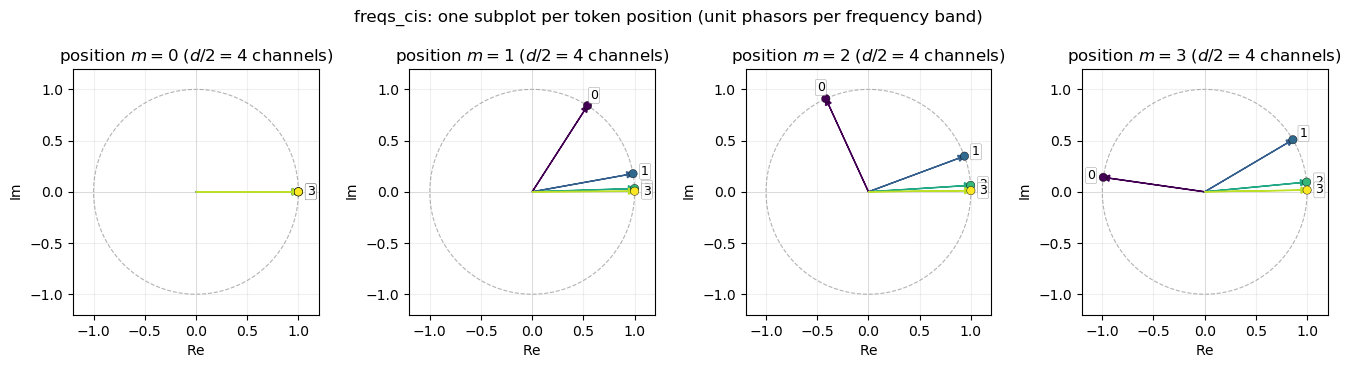

In [11]:
import numpy as np
import matplotlib.pyplot as plt

n_pos = freqs_cis.shape[0]
ncols = min(n_pos, 4)
nrows = (n_pos + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.4 * nrows), squeeze=False)
axes_flat = axes.ravel()

th_circle = np.linspace(0, 2 * np.pi, 200)
for m in range(n_pos):
    ax = axes_flat[m]
    z = freqs_cis[m].detach().cpu().numpy()
    re, im = np.real(z), np.imag(z)
    ax.plot(np.cos(th_circle), np.sin(th_circle), color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.axhline(0, color="lightgray", lw=0.5)
    ax.axvline(0, color="lightgray", lw=0.5)
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(z)))
    for j in range(len(z)):
        ax.arrow(0, 0, re[j], im[j], head_width=0.06, head_length=0.06, fc=colors[j], ec=colors[j], length_includes_head=True, zorder=3)
    ax.scatter(re, im, c=np.arange(len(z)), cmap="viridis", s=36, zorder=4, edgecolors="k", linewidths=0.3)
    label_radius = 1.12
    for j in range(len(z)):
        ax.text(
            label_radius * re[j],
            label_radius * im[j],
            str(j),
            ha="center",
            va="center",
            fontsize=9,
            color="k",
            zorder=6,
            bbox=dict(boxstyle="round,pad=0.12", facecolor="white", edgecolor="0.5", linewidth=0.3, alpha=0.9),
        )
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(r"$\mathrm{Re}$")
    ax.set_ylabel(r"$\mathrm{Im}$")
    ax.set_title(rf"position $m={m}$ ($d/2={dim // 2}$ channels)")
    ax.grid(True, alpha=0.2)

for k in range(n_pos, len(axes_flat)):
    axes_flat[k].set_visible(False)

plt.suptitle("freqs_cis: one subplot per token position (unit phasors per frequency band)", y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# 保留max_seq_len和head_dim，其他维度都为1(batch_size, n_heads)
def reshape_for_broadcast(freqs_cis: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    ndim = x.ndim
    shape = [d if i == 1 or i == ndim - 1 else 1 for i, d in enumerate(x.shape)]
    return freqs_cis.view(*shape)

xq = torch.randn(2, 4, 2, 8) # shape (batch_size, seq_len,n_heads, head_dim)
# 对最后一个纬度：head_dim进行拆分，相邻的两个向量拆成实部和虚部
# shape (batch_size, seq_len, n_heads, head_dim // 2)
xq_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
print(f"xq_[0][0]: {xq_[0][0]}")

reshape_freq = reshape_for_broadcast(freqs_cis, xq_) # shape (b1tch_size, seq_len, 1, head_dim // 2)
print(f"reshape_freq.shape: {reshape_freq.shape}")
print(f"reshape_freq[0][0]: {reshape_freq[0][0]}")


xq_ = xq_ * reshape_freq
print(f"xq_.shape: {xq_.shape}")


xq_[0][0]: tensor([[-0.0518-0.3906j, -1.8363+0.8157j,  0.2614+1.0085j,  0.9958+0.6228j],
        [-1.0319-1.1714j, -0.6201+1.6382j,  1.0993-0.3336j,  0.5285+1.0677j]])
reshape_freq.shape: torch.Size([1, 4, 1, 4])
reshape_freq[0][0]: tensor([[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j]])
xq_.shape: torch.Size([2, 4, 2, 4])


## 两个复数相乘的可视化

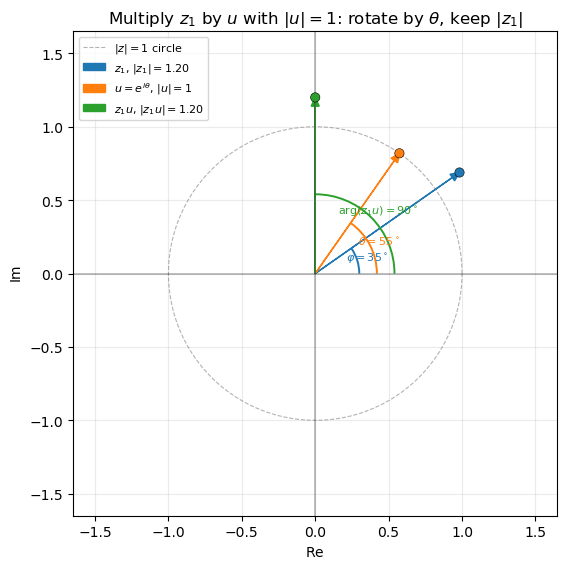

|z1| = 1.200000, |u| = 1.000000, |z1*u| = 1.200000
arg(z1)+arg(u) = 1.570796, arg(z1*u) = 1.570796


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# z1: general complex; u: on unit circle (|u| = 1)
# z1 * u rotates z1 by arg(u); |z1 * u| = |z1| * |u| = |z1|
z1 = 1.2 * np.exp(1j * np.deg2rad(35))
theta_u = np.deg2rad(55)
u = np.exp(1j * theta_u)
z_prod = z1 * u

fig, ax = plt.subplots(figsize=(5.8, 5.8))
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color="gray", ls="--", lw=0.8, alpha=0.6, label=r"$|z|=1$ circle")

from matplotlib.patches import Arc

phi1 = np.angle(z1)
phi_u = np.angle(u)
phi_p = np.angle(z_prod)


def add_angle_arc(ax, radius, angle_rad, color, label, lw=1.4):
    arc = Arc(
        (0, 0),
        2 * radius,
        2 * radius,
        angle=0,
        theta1=0,
        theta2=np.rad2deg(angle_rad),
        color=color,
        lw=lw,
        zorder=2,
    )
    ax.add_patch(arc)
    mid = angle_rad / 2
    pad = 0.07
    tx = (radius + pad) * np.cos(mid)
    ty = (radius + pad) * np.sin(mid)
    ax.text(tx, ty, label, ha="center", va="center", fontsize=8, color=color)


add_angle_arc(ax, 0.30, phi1, "C0", rf"$\varphi={np.rad2deg(phi1):.0f}^\circ$")
add_angle_arc(ax, 0.42, phi_u, "C1", rf"$\theta={np.rad2deg(phi_u):.0f}^\circ$")
add_angle_arc(ax, 0.54, phi_p, "C2", rf"$\mathrm{{arg}}(z_1 u)={np.rad2deg(phi_p):.0f}^\circ$")


def arrow_from_origin(z, **kwargs):
    ax.arrow(
        0,
        0,
        z.real,
        z.imag,
        head_width=0.055,
        head_length=0.06,
        length_includes_head=True,
        **kwargs,
    )


arrow_from_origin(z1, fc="C0", ec="C0", label=rf"$z_1$, $|z_1|={np.abs(z1):.2f}$")
arrow_from_origin(u, fc="C1", ec="C1", label=r"$u=e^{i\theta}$, $|u|=1$")
arrow_from_origin(z_prod, fc="C2", ec="C2", label=rf"$z_1 u$, $|z_1 u|={np.abs(z_prod):.2f}$")

ax.scatter([z1.real, u.real, z_prod.real], [z1.imag, u.imag, z_prod.imag], c=["C0", "C1", "C2"], s=45, zorder=5, edgecolors="k", linewidths=0.4)

ax.axhline(0, color="k", lw=0.35)
ax.axvline(0, color="k", lw=0.35)
ax.set_aspect("equal")
lim = 1.65
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$\mathrm{Re}$")
ax.set_ylabel(r"$\mathrm{Im}$")
ax.set_title(r"Multiply $z_1$ by $u$ with $|u|=1$: rotate by $\theta$, keep $|z_1|$")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"|z1| = {np.abs(z1):.6f}, |u| = {np.abs(u):.6f}, |z1*u| = {np.abs(z_prod):.6f}")
print(f"arg(z1)+arg(u) = {np.angle(z1)+np.angle(u):.6f}, arg(z1*u) = {np.angle(z_prod):.6f}")

In [ ]:
def apply_rotary_emb(xq: torch.Tensor,
                     xk: torch.Tensor,
                     freqs_cis: torch.Tensor) -> torch.Tensor:
    # 对最后一个纬度：head_dim进行拆分，相邻的两个向量拆成实部和虚部
    # shape (batch_size, seq_len, n_heads, head_dim // 2)
    xq_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
    xk_ = torch.view_as_complex(xk.float().reshape(*xk.shape[:-1], -1, 2))

    # 保留max_seq_len和head_dim，其他维度都为1(batch_size, n_heads)
    # 将freqs_cis的维度扩展为(1, seq_len, 1, head_dim // 2)
    freqs_q_cis = reshape_for_broadcast(freqs_cis, xq_)
    freqs_k_cis = reshape_for_broadcast(freqs_cis, xk_)

    # view_as_real: 将复数转换为实数，shape (batch_size, seq_len, n_heads, head_dim // 2, 2)
    # flatten: 将最后一个纬度展平，shape (batch_size, seq_len, n_heads, head_dim)
    xq_ = torch.view_as_real(xq_ * freqs_q_cis).flatten(3)
    xk_ = torch.view_as_real(xk_ * freqs_k_cis).flatten(3)
    return xq_.type(xq.dtype), xk_.type(xk.dtype)


xq = torch.randn(2, 4, 2, 8)
xk = torch.randn(2, 4, 2, 8)
xq, xk = apply_rotary_emb(xq, xk, freqs_cis)
print(f"xq.shape: {xq.shape}")
print(f"xk.shape: {xk.shape}")

xq.shape: torch.Size([2, 4, 2, 8])
xk.shape: torch.Size([2, 4, 2, 8])


# 为什么高维的 RoPE / 相对位置，最后常写成「二维一块」的复数乘法，再和 q、k 一起算注意力？

先澄清一点：**并不是把整个高维向量压成「一个」二维复数。**  
而是：head 维度 $d$（偶数）被**两两分组**，得到 $d/2$ 个**互不相干**的二维子空间；**每一组** $(2k,\,2k{+}1)$ 看成**一个**复数的实部与虚部。因此是 **$d/2$ 个复数分量并排**，每个分量里做**各自的**旋转（各自频率 $\theta_k$），不是全局只有一个复数。

## 1. 从二维推导到「分块」高维

RoPE 的出发点是：在**二维**里用旋转（或等价地乘 $e^{i m\theta}$）去编码位置，使得注意力内积只依赖相对位置 $m-n$。  
推广到 $d$ 维时，自然做法是：用一个**分块对角**的旋转——每一对维度一个 $2\times 2$ 旋转块，不同块用**不同**基频 $\theta_k$（例如与 $\theta_0^{-2k/d}$ 同型的频率表），这样既保留「相对位置」性质，又让不同维度对位置频率的敏感度不同。

所以：**高维向量仍是 $d$ 维实向量**；只是实现上把它看成 **$d/2$ 个复数**（每复数 2 个实数），方便用**复数乘法**一次完成一个 $2\times 2$ 旋转。

## 2. 为什么是「复数乘法」而不是手写矩阵

对第 $k$ 个二维块，旋转 $m\theta_k$ 的矩阵与「乘以单位复数 $e^{i m\theta_k}$」在代数上**完全等价**（前面小节里已把展开式与旋转矩阵对齐）。  
把相邻两维 `view_as_complex` 后做 **逐元素复数乘**（与预计算的 `freqs_cis` 相乘），等价于对 $d/2$ 个块各做一次旋转，**更紧凑、更好向量化**。

## 3. 和 q、k、注意力有什么关系

- **q、k** 仍是高维（例如每个 head 一条 $d$ 维向量）；RoPE 作用在**线性投影之后**的 $q$、$k$ 上（实现里常对 $q$、$k$ 做同样的「按位置旋转」）。
- 对每个复数分量（每个二维块），可写成示意：$\tilde q_{m,k} = q_{m,k}\, e^{i m\theta_k}$，$\tilde k_{n,k} = k_{n,k}\, e^{i n\theta_k}$（具体 reshape 以代码为准）。
- 算注意力得分时，内积在**各分量上**会出现依赖 $m-n$ 的相位组合，从而体现**相对位置**，而不是只用绝对位置各自编码再简单相加。

**小结**：高维没有「变成只有一个二维复数」；而是 **$d \to d/2$ 个复数通道**，每通道一次二维旋转；**复数乘法是实现每个旋转块的简洁写法**，并与 **q、k 的分块**配合，得到带相对位置信息的注意力。
